<a href="https://colab.research.google.com/github/ymuto0302/RW2024_Re/blob/main/SVM_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVMを用いた異なるIrisデータセットの分類と可視化

## 環境設定とデータ準備：

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

# データセットの読み込みと前処理
iris = load_iris()
X, y = iris.data, iris.target

# データの標準化
# (注) SVM はスケールに対して敏感ななため，スケーリングが必須
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# データの分割
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

## SVMモデルの構築と評価

In [2]:
def train_and_evaluate_svm(X_train, X_test, y_train, y_test, kernel, C=1.0, degree=3, gamma='scale'):
    svm = SVC(kernel=kernel, C=C, degree=degree, gamma=gamma)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Kernel: {kernel}, Accuracy: {accuracy:.2f}")
    print(classification_report(y_test, y_pred))
    return svm

# 異なるカーネルでSVMを訓練・評価
kernels = ['linear', 'poly', 'rbf']
for kernel in kernels:
    train_and_evaluate_svm(X_train, X_test, y_train, y_test, kernel)

Kernel: linear, Accuracy: 0.98
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45

Kernel: poly, Accuracy: 0.98
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.93      1.00      0.96        13
           2       1.00      0.92      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45

Kernel: rbf, Accuracy: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.

## ハイパーパラメータCの影響分析:

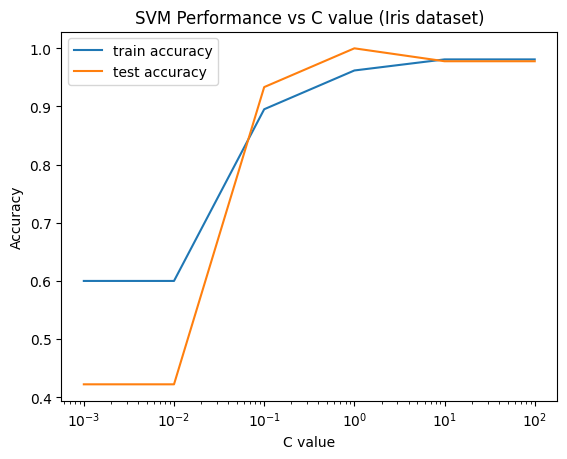

In [5]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
accuracies_train = []
accuracies_test = []

for C in C_values:
    svm = SVC(kernel='rbf', C=C)

    # 学習
    svm.fit(X_train, y_train)

    # 学習データで予測
    y_train_pred = svm.predict(X_train)
    accuracies_train.append(accuracy_score(y_train, y_train_pred))

    # テストデータで予測
    y_test_pred = svm.predict(X_test)
    accuracies_test.append(accuracy_score(y_test, y_test_pred))

plt.plot(C_values, accuracies_train, label="train accuracy")
plt.plot(C_values, accuracies_test, label="test accuracy")
plt.legend() # 凡例の表示
plt.xscale('log')
plt.xlabel('C value')
plt.ylabel('Accuracy')
plt.title('SVM Performance vs C value (Iris dataset)')
plt.show()